<a href="https://colab.research.google.com/github/VsAthul/Fun-with-Jupyter/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)
my_data.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
185,57,F,NORMAL,NORMAL,25.893,drugY
187,47,M,HIGH,HIGH,10.403,drugA
65,68,F,NORMAL,NORMAL,27.050,drugY
86,51,F,NORMAL,HIGH,13.597,drugX
103,56,M,NORMAL,HIGH,8.966,drugX


In [3]:
my_data.shape

(200, 6)

In [4]:
my_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [8]:
d1 = my_data.select_dtypes('object').columns.tolist()
label_encoder = LabelEncoder()
for x in d1:
  my_data[x]= label_encoder.fit_transform(my_data[x])
my_data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4
...,...,...,...,...,...,...
195,56,0,1,0,11.567,2
196,16,1,1,0,12.006,2
197,52,1,2,0,9.894,3
198,23,1,2,1,14.020,3


In [9]:
my_data[['Age','Sex',	'BP',	'Cholesterol',	'Na_to_K',	'Drug']].corr()['Drug']

,Drug
Age,-0.004828
Sex,-0.098573
BP,0.372868
Cholesterol,0.055629
Na_to_K,0.589120
Drug,1.000000


In [14]:
x.head(1)

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355


In [21]:
x=my_data.drop(columns='Drug', axis=1)
y=my_data['Drug']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=3)


In [23]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=4)
model.fit(x_train,y_train)
pred = model.predict(x_test)
print("Accuracy : ", accuracy_score(y_test, pred))

Accuracy :  1.0


[Text(0.625, 0.9, 'x[4] <= 14.829\nentropy = 1.921\nsamples = 160\nvalue = [19, 12, 12, 38, 79]'),
 Text(0.5, 0.7, 'x[2] <= 0.5\nentropy = 1.819\nsamples = 81\nvalue = [19, 12, 12, 38, 0]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[0] <= 50.5\nentropy = 0.963\nsamples = 31\nvalue = [19, 12, 0, 0, 0]'),
 Text(0.125, 0.3, 'entropy = 0.0\nsamples = 19\nvalue = [19, 0, 0, 0, 0]'),
 Text(0.375, 0.3, 'entropy = 0.0\nsamples = 12\nvalue = [0, 12, 0, 0, 0]'),
 Text(0.75, 0.5, 'x[3] <= 0.5\nentropy = 0.795\nsamples = 50\nvalue = [0, 0, 12, 38, 0]'),
 Text(0.625, 0.3, 'x[2] <= 1.5\nentropy = 0.999\nsamples = 23\nvalue = [0, 0, 12, 11, 0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 12\nvalue = [0, 0, 12, 0, 0]'),
 Text(0.75, 0.1, 'entropy = 0.0\nsamples = 11\nvalue = [0, 0, 0, 11, 0]'),
 Text(0.875, 0.3, 'entropy = 0.0\nsamples = 27\nvalue = [0, 0, 0, 27, 0]'),
 Text(0.75, 0.7, 'entropy = 0.0\nsamples = 79\nvalue = [0, 0, 0, 0, 79]'),
 Text(0.6875, 0.8, '  False')]

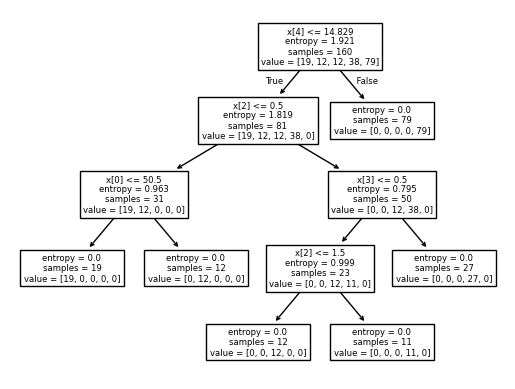

In [24]:
plot_tree(model)